# BCNexus — Stage-wise Workflow
**Author:** Md Eliasinul Islam

Run the CLEWs pipeline **one stage at a time**, via the Python API or the CLI — both drive the same `RunModel.stage_*` methods, so results are identical.

| Stage | Python | CLI |
|---|---|---|
| 1. Build SETs/params | `m.stage_build(include_livestock=INCLUDE_LIVESTOCK)` | `python -m bcnexus.stages build ...` |
| 2. Scenario overrides | `m.stage_scenario()` | `... scenario-overlay ...` |
| 3. otoole datafile | `m.stage_datafile()` | `... datafile ...` |
| 4. LP file (glpsol) | `m.stage_lp()` | `... lp ...` |
| 5. Solve (+duals/reports) | `m.stage_solve()` | `... solve ...` |
| 6. Result CSVs (otoole) | `m.stage_results()` | `... results ...` |

Why stages: after a crash (or a config tweak) you re-run only the affected step — e.g. edit `scenarios_bcnexus.yaml`, then re-run stages 2→6 without rebuilding.

> Run this notebook from the **repo root** (where `config/` and `data/` live).

## 0. Run definition — edit these

In [1]:
SCENARIO      = "Base_CNZ_noCCS"   # key in config/scenarios_bcnexus.yaml
STORAGE_ALGO  = "Kotzur"           # Kotzur | Niet
HOUR_GROUPING = 4
N_CLUSTERS    = 1
SOLVER        = "gurobi"           # gurobi | cbc
THREADS       = 16

INCLUDE_LIVESTOCK = False  # True currently duplicates OAR rows (PWRBCWB01) -> GLPK "already defined"

---
# Option A — Python API
One `RunModel` instance; call stages in order. You can stop, inspect files, and continue — but note stages 3→5 share paths in memory, so within a *fresh* session start from the stage whose inputs already exist on disk (each stage re-derives what it needs).

In [2]:
from bcnexus.clews.runner import RunModel

m = RunModel(
    run_scenario=SCENARIO,
    storage_algorithm=STORAGE_ALGO,
    clustering_attributes={"hour_grouping": HOUR_GROUPING, "n_clusters": N_CLUSTERS},
)

└> Initiated CLEWs Model Runner for 'Base_CNZ_noCCS' scenario with 'Kotzur' storage algorithm
 └>  Input CSVS set to: data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs
____________________________________________________________________________________________________
     CLEWs Model Builder
____________________________________________________________________________________________________
************************
Scenario: Base_CNZ_noCCS
************************
ℹ️  Using configuration file at: config/scenarios_bcnexus.yaml
ℹ️  Clustering attributes: {'hour_grouping': 4, 'n_clusters': 1}
ℹ️  Storage Algorithm: Kotzur
 └> Extracting class attributes e.g. directories, static values/ranges, constants etc.
bcnexus.attributes_parser | CLEWs snapshot configuration: start_year=2021, last_year=2050
ℹ️  bcnexus.attributes_parser | BCNexus CLEWs model is structured as SINGLE region model. Current region set to: REGION1.
ℹ️  bcnexus.attributes_parser | Fetching OTOOLE confi

In [3]:
# Stage 1 — CLEWs builder: SETs, params, temporal profiles, storage schema
built_csvs = m.stage_build(include_livestock=INCLUDE_LIVESTOCK)
built_csvs

└> CLEWs Builder: SETs and Params for scenario: Base_CNZ_noCCS
 └> checking input CSVs...
 └> Copying all CSV files : 'data/clews_data/csv_template' >> 'data/clews_data/clews_build_data/input_csvs'
  └> Copied: ReserveMarginTagFuel.csv
  └> Copied: DaySplit.csv
  └> Copied: REMinProductionTarget.csv
  └> Copied: RETagFuel.csv
  └> Copied: ModelPeriodEmissionLimit.csv
  └> Copied: MinStorageCharge.csv
  └> Copied: OperationalLifeStorage.csv
  └> Copied: TradeRoute.csv
  └> Copied: TotalAnnualMaxCapacityInvestment.csv
  └> Copied: DiscountRateStorage.csv
  └> Copied: TechnologyToStorage.csv
  └> Copied: DaysInDayType.csv
  └> Copied: STORAGE.csv
  └> Copied: CapitalCostStorage.csv
  └> Copied: OperationalLife.csv
  └> Copied: TotalTechnologyAnnualActivityLowerLimit.csv
  └> Copied: Conversionls.csv
  └> Copied: MODE_OF_OPERATION.csv
  └> Copied: DAYSCRO.csv
  └> Copied: TIMESLICE.csv
  └> Copied: ReserveMargin.csv
  └> Copied: StorageMaxDischargeRate.csv
  └> Copied: CapitalCost.csv
  └>

PosixPath('data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs')

In [4]:
# Stage 2 — scenario overrides from config/scenarios_bcnexus.yaml
m.stage_scenario()

└> Loading scenario config @ {'Demand': {}, 'EMISSION': {}, 'TECHS': {'CCS01': {'capital_cost': 9999, 'total_annual_max_capacity': 0, 'operational_life': 25, 'total_annual_max_capacity_investment': [0]}, 'HDG01': {'total_annual_max_capacity': 0.2, 'total_annual_max_capacity_investment': [0, 0, 0, 0, 0, 1]}}}
  └─> Processing Scenario Data...
  └─> File Updated: data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs/TECHNOLOGY.csv
  └─> File Updated : config/clews_builder.yaml
  └> Processing category: Demand
  └> Processing category: EMISSION
  └> Processing category: TECHS
  └─> Data updated for CCS01 in : data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs/CapitalCost.csv
  └─> Data updated for HDG01 in : data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs/CapitalCost.csv
  └> Processing category: Demand
  └> Processing category: EMISSION
  └> Processing category: TECHS
  └─> Data updated for CCS01 in : data/clews_data/clews_build_da

PosixPath('data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs')

In [5]:
# Stage 3 — otoole datafile + model file
data_file, model_file = m.stage_datafile()
print(data_file, model_file, sep="\n")

└> Preparing model and data files.
DATA_INFILE: data/clews_data/clews_build_data/Model_Kotzur/Base_CNZ_noCCS/Base_CNZ_noCCS_data.txt IS_DIR? False
 └> Preprocessing data and model file for case: Kotzur
  └> data file processed and saved as : data/clews_data/clews_build_data/Model_Kotzur/Base_CNZ_noCCS/Base_CNZ_noCCS_dataProcessed.txt
  └> model file processed and saved as : data/clews_data/clews_build_data/Model_Kotzur/Base_CNZ_noCCS/Kotzur_Model_processed.txt
data/clews_data/clews_build_data/Model_Kotzur/Base_CNZ_noCCS/Base_CNZ_noCCS_dataProcessed.txt
data/clews_data/clews_build_data/Model_Kotzur/Base_CNZ_noCCS/Kotzur_Model_processed.txt


In [6]:
# Stage 4 — LP file via glpsol
lp_file = m.stage_lp()
lp_file

└> Preparing the LP file
 └> Creating LP file: data/clews_data/clews_build_data/Model_Kotzur/Base_CNZ_noCCS/Base_CNZ_noCCS.lp from Model : data/clews_data/clews_build_data/Model_Kotzur/Base_CNZ_noCCS/Kotzur_Model_processed.txt, Data : data/clews_data/clews_build_data/Model_Kotzur/Base_CNZ_noCCS/Base_CNZ_noCCS_dataProcessed.txt
 ─> GLPSOL: GLPK LP/MIP Solver, v4.65
 ─> Parameter(s) specified in the command line:
 ─> -m data/clews_data/clews_build_data/Model_Kotzur/Base_CNZ_noCCS/Kotzur_Model_processed.txt
 ─> -d data/clews_data/clews_build_data/Model_Kotzur/Base_CNZ_noCCS/Base_CNZ_noCCS_dataProcessed.txt
 ─> --wlp data/clews_data/clews_build_data/Model_Kotzur/Base_CNZ_noCCS/Base_CNZ_noCCS.lp
 ─> --check
 ─> Reading model section from data/clews_data/clews_build_data/Model_Kotzur/Base_CNZ_noCCS/Kotzur_Model_processed.txt...
 ─> 214 lines were read
 ─> Reading data section from data/clews_data/clews_build_data/Model_Kotzur/Base_CNZ_noCCS/Base_CNZ_noCCS_dataProcessed.txt...
 ─> data/clews_

PosixPath('data/clews_data/clews_build_data/Model_Kotzur/Base_CNZ_noCCS/Base_CNZ_noCCS.lp')

└> Solving the LP problem with gurobi solver
 └> Using 16 threads to solve the model using Gurobi solver. If the solver fails to load/run due to memory issues, please use thread < your hardware limitation (cores)
  └> Gurobi update : 

  └> --------------------------------------------------
Set parameter Username


2026-07-18 21:12:35,418 - INFO - Set parameter Username


Set parameter LicenseID to value 2812656


2026-07-18 21:12:35,419 - INFO - Set parameter LicenseID to value 2812656


Academic license - for non-commercial use only - expires 2027-04-23


...

2026-07-18 21:12:36,353 - INFO - cost: 314356 rows, 294600 columns, 2651148 nonzeros


Set parameter LogToConsole to value 0


2026-07-18 21:12:36,353 - INFO - Set parameter LogToConsole to value 0
2026-07-18 21:12:36,353 - INFO - Set parameter Method to value 2
2026-07-18 21:12:36,354 - INFO - Set parameter Threads to value 16
2026-07-18 21:12:36,354 - INFO - Set parameter NumericFocus to value 2
2026-07-18 21:12:36,354 - INFO - Set parameter Crossover to value 0
2026-07-18 21:12:36,354 - INFO - Set parameter ScaleFlag to value 2
2026-07-18 21:12:36,354 - INFO - Set parameter BarHomogeneous to value 1
2026-07-18 21:12:36,354 - INFO - Set parameter LogFile to value "results/clews/Model_Kotzur_Base_CNZ_noCCS/6ts/gurobi.log"
2026-07-18 21:12:36,354 - INFO - Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (linux64 - "Ubuntu 20.04.6 LTS")
2026-07-18 21:12:36,354 - INFO - 
2026-07-18 21:12:36,354 - INFO - CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
2026-07-18 21:12:36,355 - INFO - Thread count: 32 physical cores, 32 logical processors, using up to 16 threads
2026-07-18 21:12:36

  └> --------------------------------------------------
  └─> Model run completed. Please check the log for detailed report.
  └> Collecting constraints reports...
  └> Summary saved to results/clews/Model_Kotzur_Base_CNZ_noCCS/6ts/constraints_summary.txt


PosixPath('results/clews/Model_Kotzur_Base_CNZ_noCCS/6ts/6ts_solution_gurobi.sol')

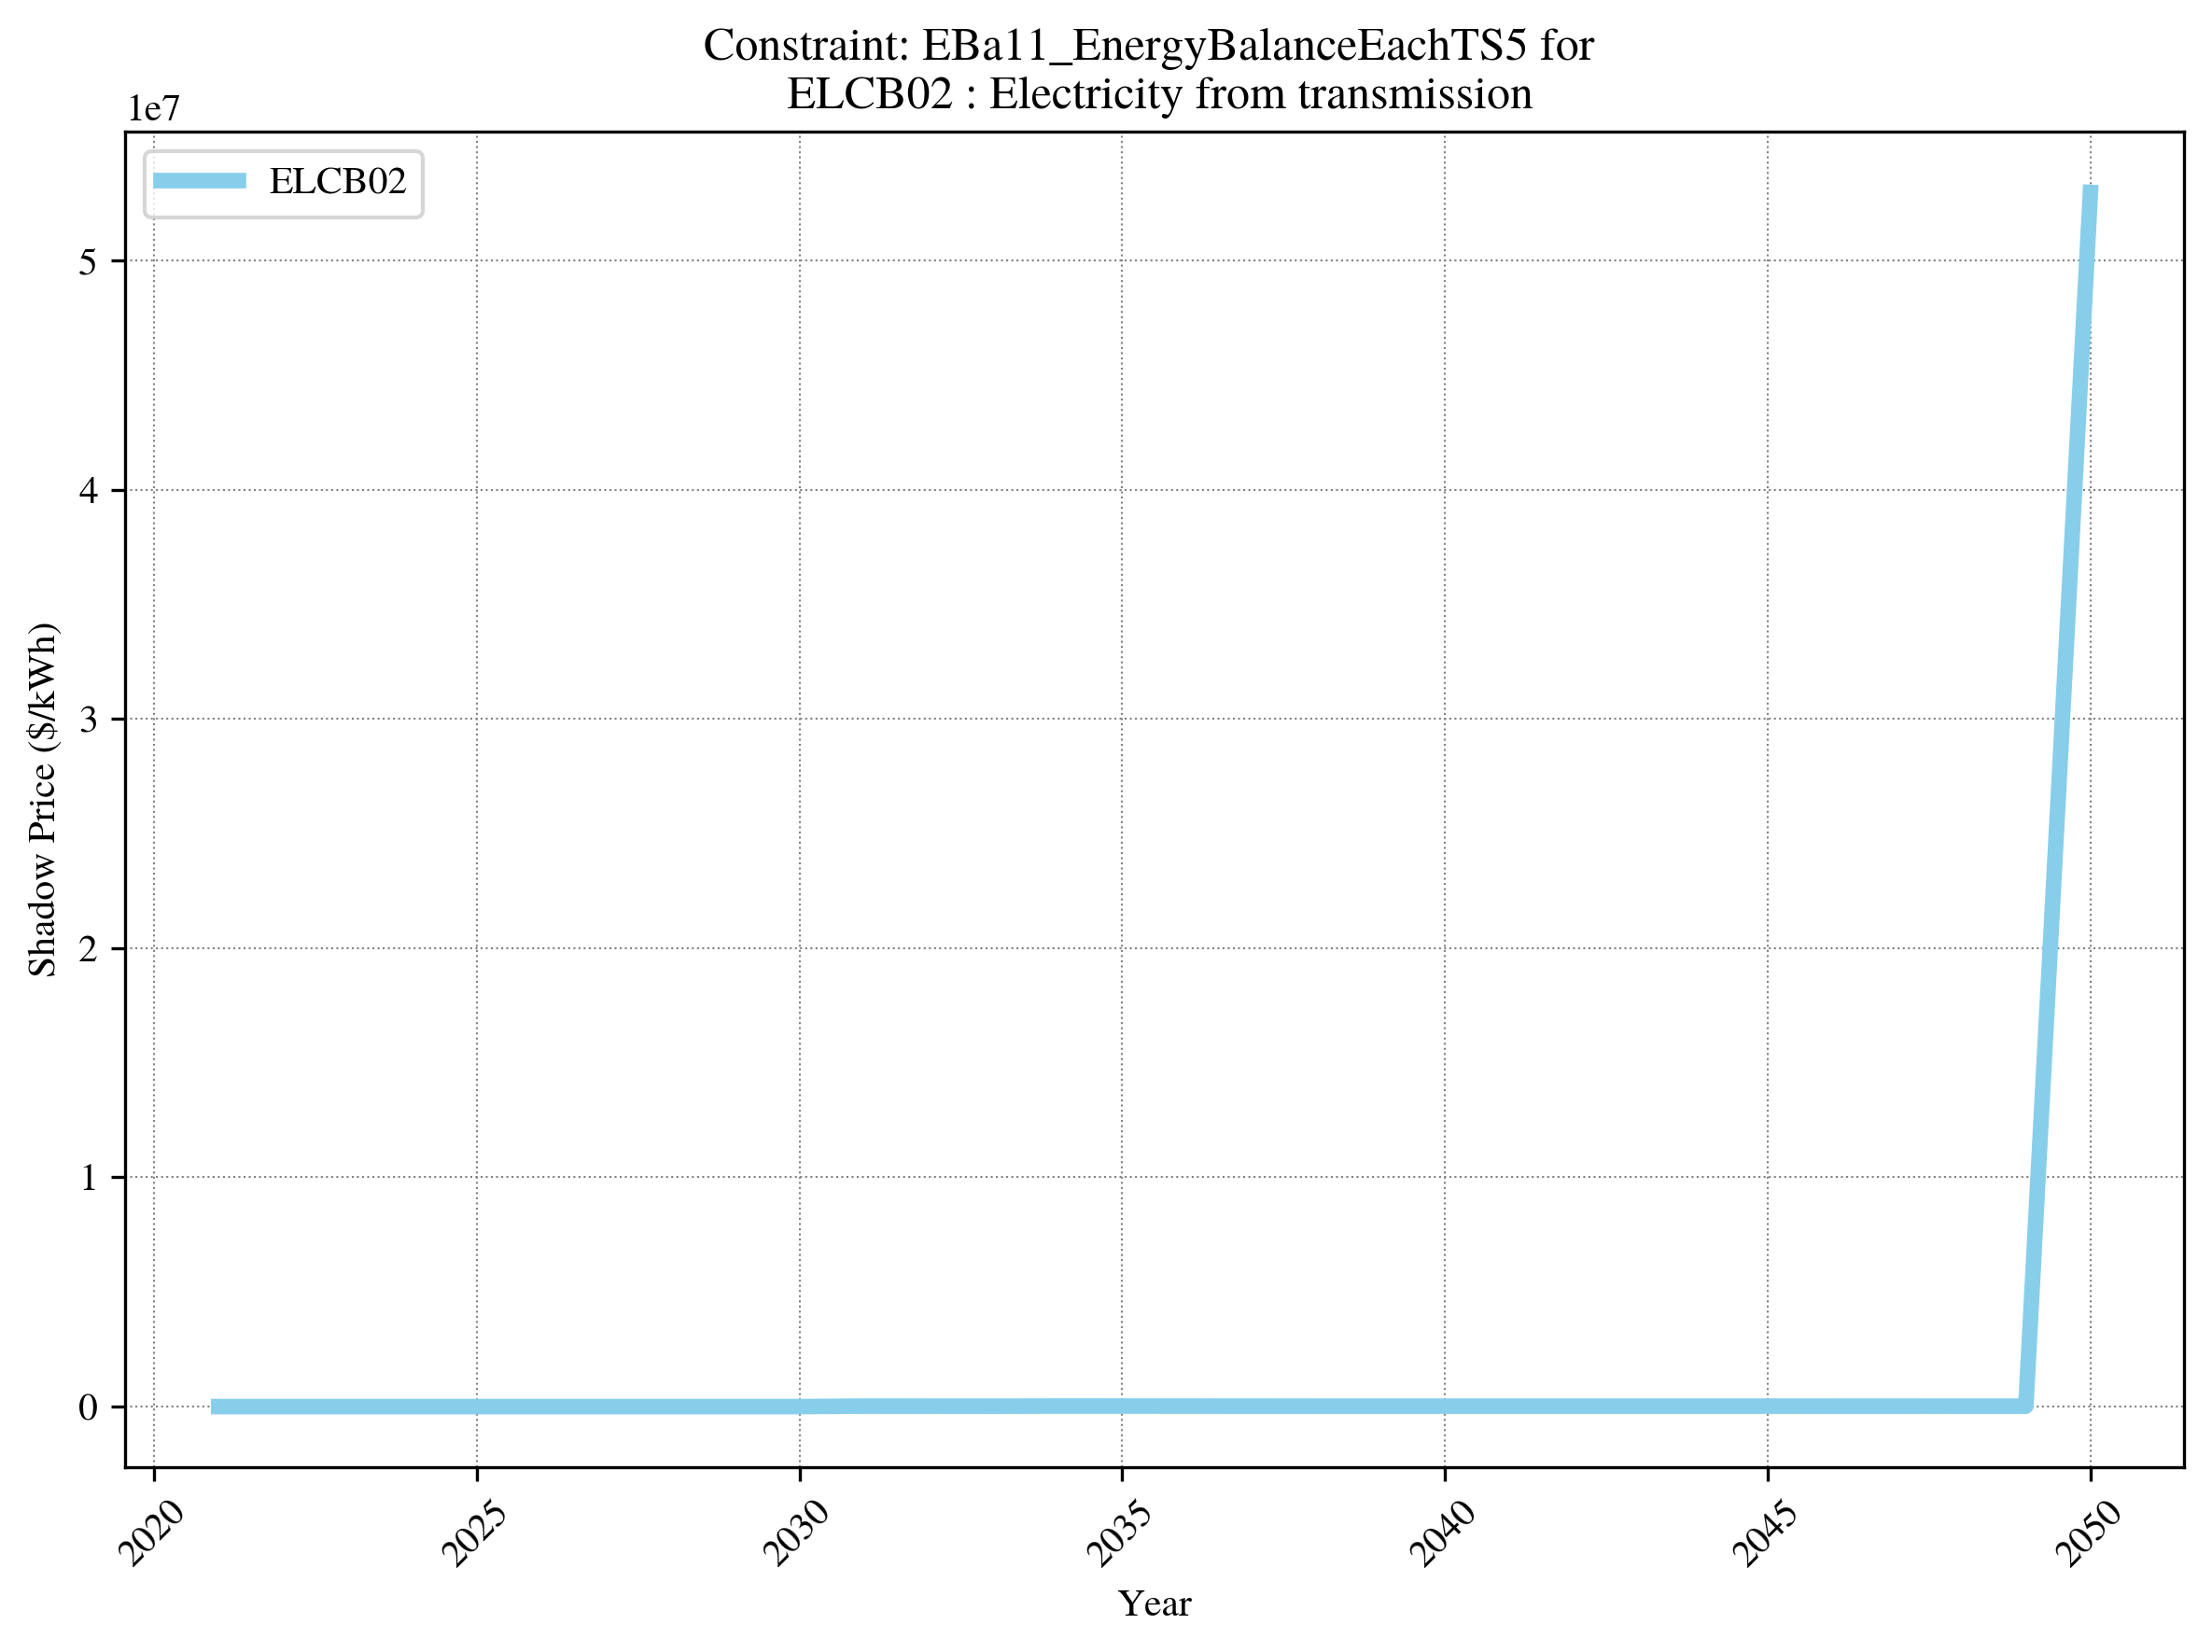

In [7]:
# Stage 5 — solve (writes .sol + duals, constraints summary, ELCB02 shadow price)
sol = m.stage_solve(solver_name=SOLVER, threads=THREADS)
sol   # None => not optimal; check the solver log in the run dir

In [8]:
# Stage 6 — extract result CSVs via otoole
results_dir = m.stage_results(solver_name=SOLVER)
results_dir  # => .../{N}ts/result_csvs_gurobi/

 └> Initiating otoole interface to extract results; input csvs : data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs , config file: models/model_Kotzur/otoole_config_Kotzur.yaml
  └> Result extraction completed and saved to results/clews/Model_Kotzur_Base_CNZ_noCCS/6ts/result_csvs_gurobi


PosixPath('results/clews/Model_Kotzur_Base_CNZ_noCCS/6ts/result_csvs_gurobi')

Inspect any intermediate quickly:

In [9]:
import pandas as pd
sorted(p.name for p in results_dir.glob("*.csv"))[:10] if results_dir else "no results yet"

['AccumulatedNewCapacity.csv',
 'AnnualEmissions.csv',
 'AnnualFixedOperatingCost.csv',
 'AnnualTechnologyEmission.csv',
 'AnnualTechnologyEmissionByMode.csv',
 'AnnualVariableOperatingCost.csv',
 'CapitalInvestment.csv',
 'Demand.csv',
 'DiscountedSalvageValue.csv',
 'DiscountedTechnologyEmissionsPenalty.csv']

---
# Option B — CLI
Same stages from the shell (what Snakemake calls). Each command is an **independent process** — safe to run days apart; every stage re-derives its paths from disk.

In [10]:
ARGS = f"-s {SCENARIO} -a {STORAGE_ALGO} -hg {HOUR_GROUPING} -nc {N_CLUSTERS}"
print(ARGS)

LIVESTOCK_FLAG = "--include-livestock" if INCLUDE_LIVESTOCK else "--no-include-livestock"

-s Base_CNZ_noCCS -a Kotzur -hg 4 -nc 1


In [11]:
!python -m bcnexus.stages build {ARGS} {LIVESTOCK_FLAG}

└> Initiated CLEWs Model Runner for 'Base_CNZ_noCCS' scenario with 'Kotzur' storage algorithm
 └>  Input CSVS set to: data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs
____________________________________________________________________________________________________
     CLEWs Model Builder
____________________________________________________________________________________________________
************************
Scenario: Base_CNZ_noCCS
************************
ℹ️  Using configuration file at: config/scenarios_bcnexus.yaml
ℹ️  Clustering attributes: {'hour_grouping': 4, 'n_clusters': 1}
ℹ️  Storage Algorithm: Kotzur
 └> Extracting class attributes e.g. directories, static values/ranges, constants etc.
bcnexus.attributes_parser | CLEWs snapshot configuration: start_year=2021, last_year=2050
ℹ️  bcnexus.attributes_parser | BCNexus CLEWs model is structured as SINGLE region model. Current region set to: REGION1.
ℹ️  bcnexus.attributes_parser | Fetching OTOOLE confi

In [12]:
!python -m bcnexus.stages scenario-overlay {ARGS}

└> Initiated CLEWs Model Runner for 'Base_CNZ_noCCS' scenario with 'Kotzur' storage algorithm
 └>  Input CSVS set to: data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs
____________________________________________________________________________________________________
     CLEWs Model Builder
____________________________________________________________________________________________________
************************
Scenario: Base_CNZ_noCCS
************************
ℹ️  Using configuration file at: config/scenarios_bcnexus.yaml
ℹ️  Clustering attributes: {'hour_grouping': 4, 'n_clusters': 1}
ℹ️  Storage Algorithm: Kotzur
 └> Extracting class attributes e.g. directories, static values/ranges, constants etc.
bcnexus.attributes_parser | CLEWs snapshot configuration: start_year=2021, last_year=2050
ℹ️  bcnexus.attributes_parser | BCNexus CLEWs model is structured as SINGLE region model. Current region set to: REGION1.
ℹ️  bcnexus.attributes_parser | Fetching OTOOLE confi

In [13]:
!python -m bcnexus.stages datafile {ARGS}

└> Initiated CLEWs Model Runner for 'Base_CNZ_noCCS' scenario with 'Kotzur' storage algorithm
 └>  Input CSVS set to: data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs
____________________________________________________________________________________________________
     CLEWs Model Builder
____________________________________________________________________________________________________
************************
Scenario: Base_CNZ_noCCS
************************
ℹ️  Using configuration file at: config/scenarios_bcnexus.yaml
ℹ️  Clustering attributes: {'hour_grouping': 4, 'n_clusters': 1}
ℹ️  Storage Algorithm: Kotzur
 └> Extracting class attributes e.g. directories, static values/ranges, constants etc.
bcnexus.attributes_parser | CLEWs snapshot configuration: start_year=2021, last_year=2050
ℹ️  bcnexus.attributes_parser | BCNexus CLEWs model is structured as SINGLE region model. Current region set to: REGION1.
ℹ️  bcnexus.attributes_parser | Fetching OTOOLE confi

In [14]:
!python -m bcnexus.stages lp {ARGS}

└> Initiated CLEWs Model Runner for 'Base_CNZ_noCCS' scenario with 'Kotzur' storage algorithm
 └>  Input CSVS set to: data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs
____________________________________________________________________________________________________
     CLEWs Model Builder
____________________________________________________________________________________________________
************************
Scenario: Base_CNZ_noCCS
************************
ℹ️  Using configuration file at: config/scenarios_bcnexus.yaml
ℹ️  Clustering attributes: {'hour_grouping': 4, 'n_clusters': 1}
ℹ️  Storage Algorithm: Kotzur
 └> Extracting class attributes e.g. directories, static values/ranges, constants etc.
bcnexus.attributes_parser | CLEWs snapshot configuration: start_year=2021, last_year=2050
ℹ️  bcnexus.attributes_parser | BCNexus CLEWs model is structured as SINGLE region model. Current region set to: REGION1.
ℹ️  bcnexus.attributes_parser | Fetching OTOOLE confi

In [15]:
!python -m bcnexus.stages solve {ARGS} --solver {SOLVER} --threads {THREADS}

└> Initiated CLEWs Model Runner for 'Base_CNZ_noCCS' scenario with 'Kotzur' storage algorithm
 └>  Input CSVS set to: data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs
____________________________________________________________________________________________________
     CLEWs Model Builder
____________________________________________________________________________________________________
************************
Scenario: Base_CNZ_noCCS
************************
ℹ️  Using configuration file at: config/scenarios_bcnexus.yaml
ℹ️  Clustering attributes: {'hour_grouping': 4, 'n_clusters': 1}
ℹ️  Storage Algorithm: Kotzur
 └> Extracting class attributes e.g. directories, static values/ranges, constants etc.
bcnexus.attributes_parser | CLEWs snapshot configuration: start_year=2021, last_year=2050
ℹ️  bcnexus.attributes_parser | BCNexus CLEWs model is structured as SINGLE region model. Current region set to: REGION1.
ℹ️  bcnexus.attributes_parser | Fetching OTOOLE confi

In [16]:
!python -m bcnexus.stages results {ARGS} --solver {SOLVER}

└> Initiated CLEWs Model Runner for 'Base_CNZ_noCCS' scenario with 'Kotzur' storage algorithm
 └>  Input CSVS set to: data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs
____________________________________________________________________________________________________
     CLEWs Model Builder
____________________________________________________________________________________________________
************************
Scenario: Base_CNZ_noCCS
************************
ℹ️  Using configuration file at: config/scenarios_bcnexus.yaml
ℹ️  Clustering attributes: {'hour_grouping': 4, 'n_clusters': 1}
ℹ️  Storage Algorithm: Kotzur
 └> Extracting class attributes e.g. directories, static values/ranges, constants etc.
bcnexus.attributes_parser | CLEWs snapshot configuration: start_year=2021, last_year=2050
ℹ️  bcnexus.attributes_parser | BCNexus CLEWs model is structured as SINGLE region model. Current region set to: REGION1.
ℹ️  bcnexus.attributes_parser | Fetching OTOOLE confi

---
# Option C — the full matrix (Snakemake)
Once single branches work, declare the scenario matrix in `workflow_v3/config.yaml` and let snakemake run all branches in parallel with resume:

In [17]:
!snakemake -s workflow_v3/Snakefile -n     # dry run: audit what would run

/bin/bash: snakemake: command not found


In [18]:
# !snakemake -s workflow_v3/Snakefile -c4  # uncomment to launch the matrix

## Notes
- Outputs land in the **deterministic** run dir `.../{N}ts/` (no more timestamped folders). Re-running a stage overwrites that branch only; run history/versioning is DVC's job (`dvc add`, see `workflow_v3/README_WORKFLOW.md`).
- `run()` (the classic one-shot) still works and is exactly stages 1→6 composed: `m.run(build=True, solver_name=SOLVER, threads=THREADS)`.
- Typical partial re-runs: scenario tweak → stages 2→6; timeslice/cluster change → stages 1→6; solver settings only → stages 5→6.